# Test lc_toc_button Extension

This notebook tests that the lc_toc_button JupyterLab extension is properly installed and enabled.
- Verify ToC button exists and click it

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpsmajtixp


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251204-171511',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpmct2gzip')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1764836112.199167 seconds


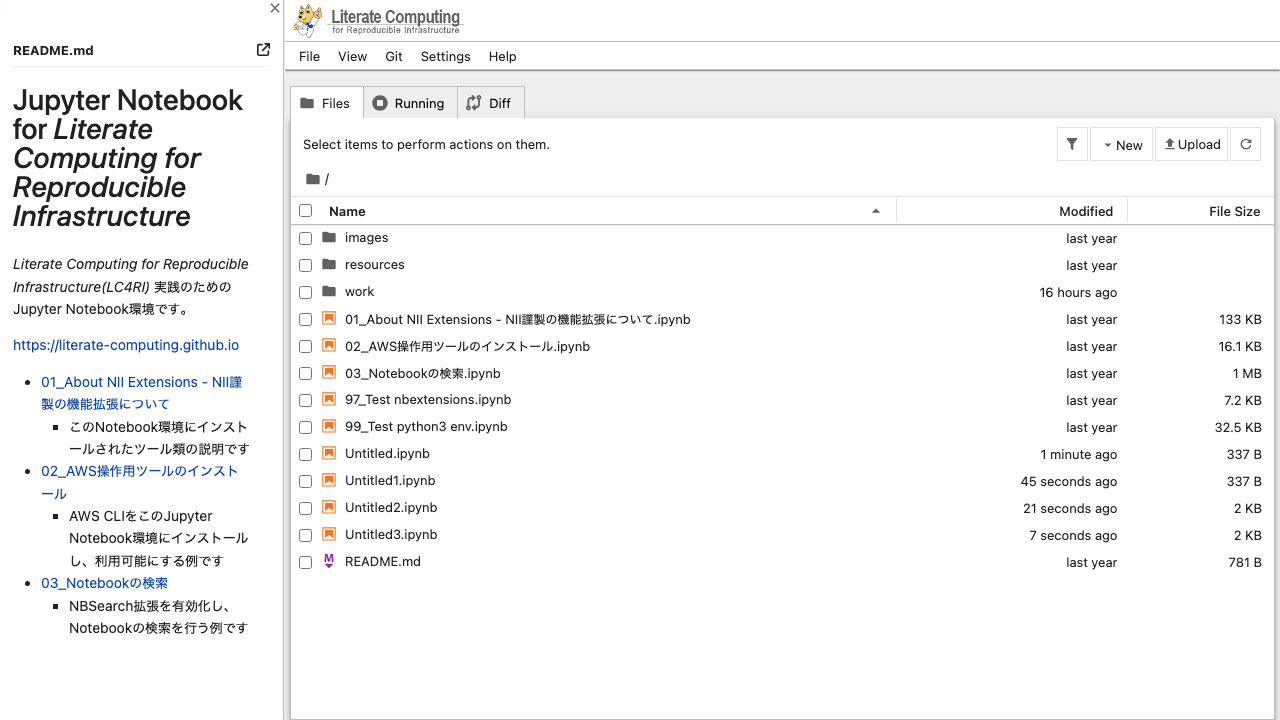

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Create a new notebook

Start epoch: 1764836114.8081422 seconds


✓ New notebook created


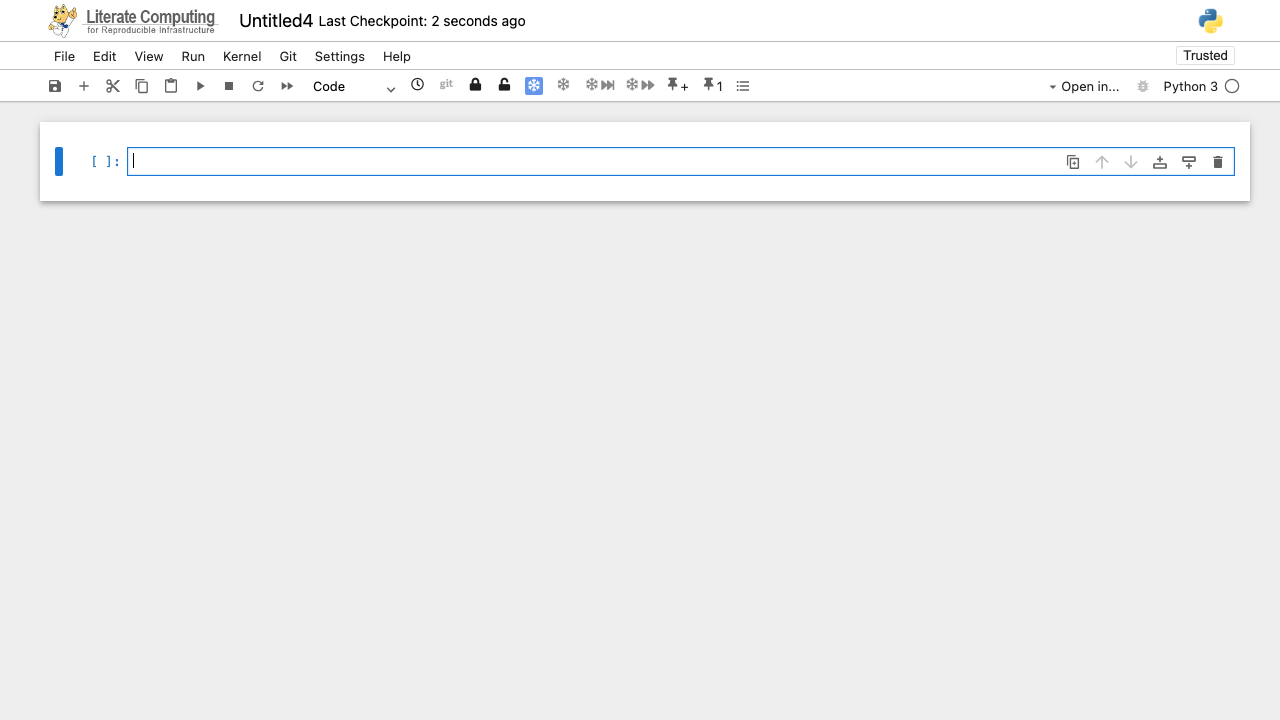

In [6]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Verify ToC button exists and click it

Start epoch: 1764836117.7852092 seconds
✓ ToC button widget is visible in the toolbar


✓ ToC panel is visible after clicking button


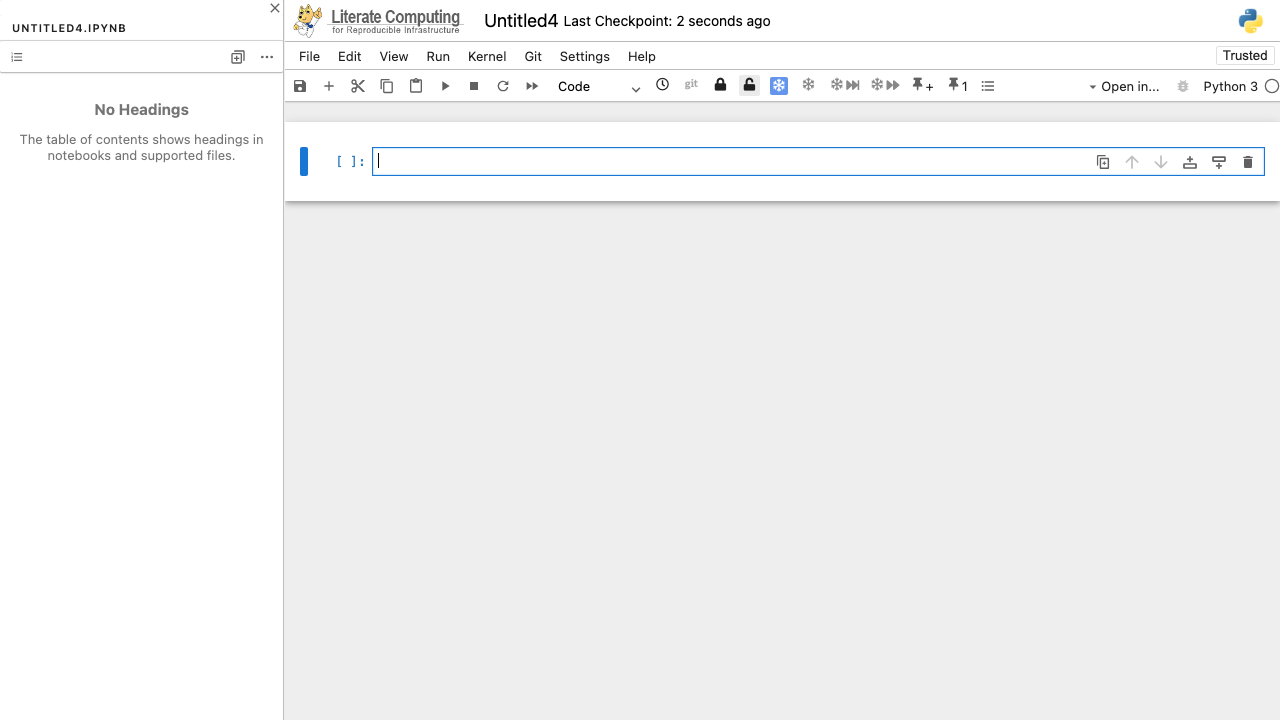

In [7]:
async def _step_toc_button(page):
    # Find ToC button
    toc_button = page.locator('[data-command="table_of_contents:table-of-contents"]')
    await expect(toc_button).to_be_visible(timeout=transition_timeout)

    print("✓ ToC button widget is visible in the toolbar")

    # Click ToC button
    await toc_button.click()
    await page.wait_for_timeout(1000)
    
    # Verify that ToC panel is now visible
    toc_panel = page.locator('#table-of-contents')
    await expect(toc_panel).to_be_visible(timeout=transition_timeout)
    
    print("✓ ToC panel is visible after clicking button")

await run_pw(_step_toc_button)

## Cleanup

In [ ]:
await finish_pw_context()

In [9]:
!rm -rf {work_dir}